# ЛР1. Один текст, разные представления

Соболь Владимир Вячеславович, К3440, ИСУ 409594

Данные: RuSentiment, файл случайных постов ВКонтакте `rusentiment_random_posts.csv`. В репозитории text-machine-lab/rusentiment данных больше нет, файл берется из форка strawberrypie/rusentiment. Из него случайно отбираются 200 текстов (seed 42), id это номер строки в исходном файле.

In [1]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from razdel import tokenize, sentenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.ticker import FuncFormatter
from sentence_transformers import SentenceTransformer
from transformers.utils import logging as tr_logging

tr_logging.disable_progress_bar()

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

SEED = 42
N_TEXTS = 200
RAW_URL = "https://raw.githubusercontent.com/strawberrypie/rusentiment/master/Dataset/rusentiment_random_posts.csv"
RAW = Path("data/raw/rusentiment_random_posts.csv")
EMB_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

COLORS = {"BoW": "#2a78d6", "TF-IDF": "#eb6834", "Embeddings": "#1baf7a"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e4e0", "axes.axisbelow": True})
COMMA = FuncFormatter(lambda v, _: f"{v:.1f}".replace(".", ","))

## 1. Загрузка и проверка данных

In [2]:
if not RAW.exists():
    RAW.parent.mkdir(parents=True, exist_ok=True)
    urlretrieve(RAW_URL, RAW)

raw = pd.read_csv(RAW)
df = (raw.sample(N_TEXTS, random_state=SEED)
         .rename_axis("id").reset_index()[["id", "text", "label"]])
df.to_csv("data/sample_200.csv", index=False)
print("исходный файл:", raw.shape, " выборка:", df.shape)
df.head()

исходный файл: (21268, 2)  выборка: (200, 3)


,id,text,label
0,16735,Ты бдица в небесаг)),skip
1,20928,Целины на 4ерной Акбулака больше нет ) открытие удалось на славу!,neutral
2,15427,А до неба рукой подать)😊😗🙊😻👸👑🌻🌙🌞🌝,positive
3,21214,хорошее кино,positive
4,10786,даунам не понять!,negative


In [3]:
def norm(s):
    return re.sub(r"\s+", " ", s.lower().replace("\u0451", "е")).strip()

print("пропуски:", df.isna().sum().to_dict())
print("пустые тексты:", (df["text"].str.strip() == "").sum())
print("точные дубликаты текста:", df["text"].duplicated().sum())
print("дубликаты после нормализации:", df["text"].map(norm).duplicated().sum())
print("дубликаты в исходном файле:", raw["text"].duplicated().sum(), "из", len(raw))
pd.concat([df["label"].value_counts(), raw["label"].value_counts(normalize=True).round(3)],
          axis=1, keys=["выборка", "доля в файле"])

пропуски: {'id': 0, 'text': 0, 'label': 0}
пустые тексты: 0
точные дубликаты текста: 0
дубликаты после нормализации: 0
дубликаты в исходном файле: 74 из 21268


,выборка,доля в файле
label,,
neutral,80,0.391
positive,44,0.218
skip,30,0.150
speech,26,0.133
negative,20,0.108


In [4]:
def words(text):
    return [t.text.lower().replace("\u0451", "е") for t in tokenize(text) if re.search(r"\w", t.text)]

df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].map(lambda t: len(words(t)))
df[["n_chars", "n_words"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
n_chars,200.0,70.6,102.5,10.0,22.0,36.0,70.0,713.0
n_words,200.0,11.1,16.3,1.0,3.0,6.0,11.0,116.0


In [5]:
df.groupby("label")["n_words"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,20.0,18.2,25.9,1.0,3.8,8.5,21.8,105.0
neutral,80.0,11.2,17.0,1.0,4.0,6.0,11.0,116.0
positive,44.0,11.3,16.9,1.0,3.0,5.5,11.2,85.0
skip,30.0,7.1,7.8,1.0,3.0,5.0,7.8,43.0
speech,26.0,9.1,9.0,1.0,4.0,5.5,12.8,43.0


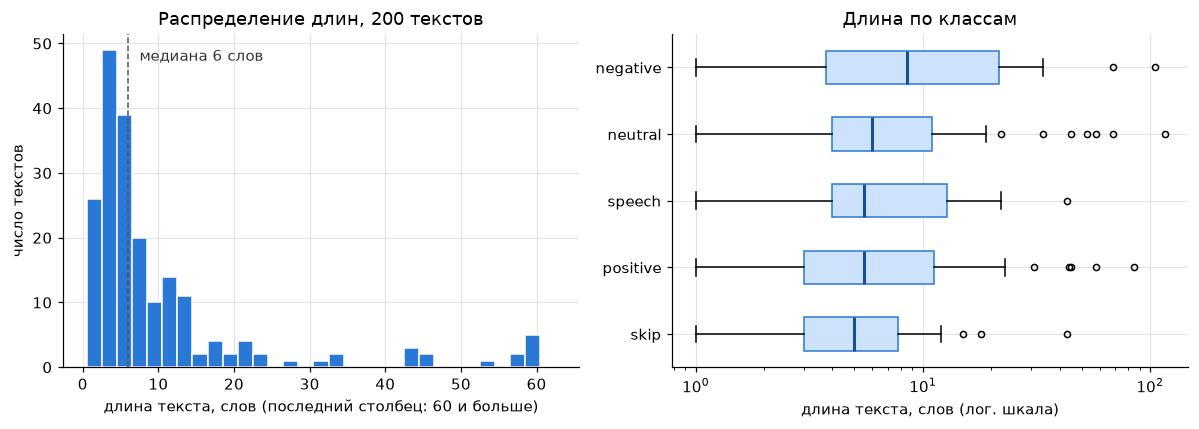

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["n_words"].clip(upper=60), bins=np.arange(0.5, 63, 2), color=COLORS["BoW"], edgecolor="white")
axes[0].axvline(df["n_words"].median(), color="#555", ls="--", lw=1)
axes[0].text(df["n_words"].median() + 1.5, axes[0].get_ylim()[1] * 0.92,
             f"медиана {df['n_words'].median():.0f} слов", color="#333")
axes[0].set_xlabel("длина текста, слов (последний столбец: 60 и больше)")
axes[0].set_ylabel("число текстов")
axes[0].set_title("Распределение длин, 200 текстов")

order = df.groupby("label")["n_words"].median().sort_values().index
axes[1].boxplot([df.loc[df["label"] == l, "n_words"] for l in order], tick_labels=order, vert=False,
                patch_artist=True, boxprops=dict(facecolor="#cde2fb", color="#2a78d6"),
                medianprops=dict(color="#184f95", lw=2), flierprops=dict(markersize=4))
axes[1].set_xscale("log")
axes[1].set_xlabel("длина текста, слов (лог. шкала)")
axes[1].set_title("Длина по классам")
plt.tight_layout()
plt.savefig("figures/lengths.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Три текста разных классов и девять преобразований

Смысл каждого варианта оценен вручную до расчета сходства. Метка «да» означает, что изменилось утверждение текста, а не только форма.

In [7]:
SOURCES = {"T1": 4462, "T2": 1290, "T3": 4680}

TRANSFORMS = [
    ("T1", "перестановка", "Я не знаю как ты меня\nтерпишь.\nНо спасибо тебе.\nПодруга.",
     "нет", "Переставлены предложения: обращение ушло в конец. Все три части и их связь на месте."),
    ("T1", "парафраз", "Подружка, ума не приложу, как ты меня выносишь. И все же благодарю тебя.",
     "нет", "Те же обращение, самоирония и благодарность, почти все слова заменены."),
    ("T1", "смена смысла", "Подруга.\nЯ знаю как ты меня\nтерпишь.\nНо спасибо тебе.",
     "да", "Удалено отрицание. Вместо признания, что автора трудно выносить, утверждение знания; союз «но» теряет опору."),
    ("T2", "перестановка", "ужасно, когда к человеку привязываешься и ждешь, как больной, от него сообщения или звонка, а ему и без тебя там хорошо.",
     "нет", "Переставлены слова внутри частей, набор слов тот же, ситуация и оценка те же."),
    ("T2", "парафраз", "Невыносимо, если прикипел к кому-то и изводишься в ожидании, пока он позвонит или напишет, а он спокойно обходится без тебя.",
     "нет", "Та же ситуация безответной привязанности и та же резко негативная оценка."),
    ("T2", "смена смысла", "прекрасно, когда привязываешься к человеку и, как больной, ждешь от него звонка или сообщения, а ему там и без тебя хорошо.",
     "да", "Оценка ситуации заменена на противоположную, буквально текст стал одобрением. Ирония возможна, но в тексте нет для нее опоры."),
    ("T3", "перестановка", "Во Владивостоке открыли памятник Илье Муромцу",
     "нет", "Порядок слов изменен, факт тот же."),
    ("T3", "парафраз", "В столице Приморья установили монумент богатырю Илье Муромцу",
     "нет", "Владивосток назван описательно, «памятник» заменен синонимом, событие то же."),
    ("T3", "смена смысла", "Памятник Илье Муромцу не открыли во Владивостоке",
     "да", "Добавлено отрицание: событие не произошло."),
]

src = df.set_index("id").loc[list(SOURCES.values()), ["text", "label"]]
pairs = pd.DataFrame(TRANSFORMS, columns=["text_key", "transform", "modified", "meaning_changed", "justification"])
pairs["source_id"] = pairs["text_key"].map(SOURCES)
pairs["label"] = pairs["source_id"].map(src["label"])
pairs["original"] = pairs["source_id"].map(src["text"])
src

,text,label
id,,
4462,Подруга.\nЯ не знаю как ты меня\nтерпишь.\nНо спасибо тебе.,positive
1290,"ужасно, когда привязываешься к человеку и, как больной, ждешь от него звонка или сообщения, а ему там и без тебя хор...",negative
4680,Памятник Илье Муромцу открыли во Владивостоке,neutral


## 3. Четыре представления

Токенизация для всех представлений одна: razdel, нижний регистр, одно написание буквы е, остаются токены со словесными символами (смайлы и пунктуация уходят). Словарь BoW и TF-IDF строится по 200 текстам вместе с девятью вариантами, иначе новые слова парафразов выпали бы из словаря и сходство было бы искажено.

In [8]:
EMOJI = re.compile("[\U0001F300-\U0001FAFF\u2600-\u27BF]")

def surface(text):
    w = words(text)
    letters = [c for c in text if c.isalpha()]
    return {
        "n_chars": len(text),
        "n_words": len(w),
        "n_sents": len(list(sentenize(text))),
        "mean_word_len": round(np.mean([len(x) for x in w]), 2) if w else 0,
        "upper_share": round(sum(c.isupper() for c in letters) / len(letters), 3) if letters else 0,
        "n_punct": sum(c in ".,!?;:-" for c in text),
        "n_excl_quest": text.count("!") + text.count("?"),
        "n_brackets_emoji": len(re.findall(r"[()]", text)) + len(EMOJI.findall(text)),
        "has_mention": int(bool(re.search(r"\[(id|club)\d+", text))),
        "has_negation": int(bool(re.search(r"\b(не|нет|ни)\b", text.lower()))),
    }

surf = pd.DataFrame([surface(t) for t in df["text"]])
surf.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
n_chars,200.0,70.60,102.54,10.0,22.00,36.00,70.00,713.0
n_words,200.0,11.06,16.34,1.0,3.00,6.00,11.00,116.0
n_sents,200.0,1.56,1.72,1.0,1.00,1.00,1.00,16.0
mean_word_len,200.0,5.36,2.38,2.0,4.32,5.00,5.68,22.0
upper_share,200.0,0.10,0.20,0.0,0.01,0.04,0.07,1.0
n_punct,200.0,3.66,6.60,0.0,0.00,2.00,3.25,46.0
n_excl_quest,200.0,1.06,2.14,0.0,0.00,0.00,1.00,16.0
n_brackets_emoji,200.0,1.18,2.08,0.0,0.00,0.00,2.00,11.0
has_mention,200.0,0.02,0.16,0.0,0.00,0.00,0.00,1.0
has_negation,200.0,0.14,0.34,0.0,0.00,0.00,0.00,1.0


In [9]:
corpus = df["text"].tolist()
all_texts = corpus + pairs["modified"].tolist()

bow = CountVectorizer(tokenizer=words, lowercase=False, token_pattern=None).fit(all_texts)
tfidf = TfidfVectorizer(tokenizer=words, lowercase=False, token_pattern=None).fit(all_texts)
X_bow = bow.transform(corpus)
X_tfidf = tfidf.transform(corpus)

model = SentenceTransformer(EMB_MODEL)
X_emb = model.encode(corpus, normalize_embeddings=True, batch_size=32)

print("BoW:", X_bow.shape, " TF-IDF:", X_tfidf.shape, " embeddings:", X_emb.shape,
      " поверхностные признаки:", surf.shape)

BoW: (200, 1331)  TF-IDF: (200, 1331)  embeddings: (200, 384)  поверхностные признаки: (200, 10)


## 4. Косинусное сходство исходного и измененного текста

In [10]:
def cos_pair(a, b):
    out = {}
    out["BoW"] = cosine_similarity(bow.transform([a]), bow.transform([b]))[0, 0]
    out["TF-IDF"] = cosine_similarity(tfidf.transform([a]), tfidf.transform([b]))[0, 0]
    ea, eb = model.encode([a, b], normalize_embeddings=True)
    out["Embeddings"] = float(ea @ eb)
    return out

sims = pd.DataFrame([cos_pair(o, m) for o, m in zip(pairs["original"], pairs["modified"])]).round(3)
res = pd.concat([pairs, sims], axis=1)
res[["text_key", "label", "transform", "meaning_changed", "BoW", "TF-IDF", "Embeddings"]]

,text_key,label,transform,meaning_changed,BoW,TF-IDF,Embeddings
0,T1,positive,перестановка,нет,1.000,1.000,0.991
1,T1,positive,парафраз,нет,0.334,0.224,0.914
2,T1,positive,смена смысла,да,0.953,0.973,0.906
3,T2,negative,перестановка,нет,1.000,1.000,0.989
4,T2,negative,парафраз,нет,0.311,0.198,0.805
5,T2,negative,смена смысла,да,0.957,0.929,0.873
6,T3,neutral,перестановка,нет,1.000,1.000,0.981
7,T3,neutral,парафраз,нет,0.289,0.262,0.809
8,T3,neutral,смена смысла,да,0.926,0.969,0.946


Фон для сравнения: среднее сходство случайных пар разных текстов из выборки. Без него трудно понять, много ли 0,6 для эмбеддингов.

In [11]:
iu = np.triu_indices(len(corpus), k=1)
baseline = {
    "BoW": cosine_similarity(X_bow)[iu].mean(),
    "TF-IDF": cosine_similarity(X_tfidf)[iu].mean(),
    "Embeddings": (X_emb @ X_emb.T)[iu].mean(),
}
emb_all = (X_emb @ X_emb.T)[iu]
print({k: round(v, 3) for k, v in baseline.items()})
print("эмбеддинги, 95-й и 99-й перцентили сходства случайных пар:",
      np.percentile(emb_all, [95, 99]).round(3))

{'BoW': np.float64(0.026), 'TF-IDF': np.float64(0.012), 'Embeddings': np.float32(0.329)}
эмбеддинги, 95-й и 99-й перцентили сходства случайных пар: [0.595 0.712]


In [12]:
out = res[["text_key", "source_id", "label", "transform", "original", "modified",
           "meaning_changed", "justification", "BoW", "TF-IDF", "Embeddings"]]
out.round(3).to_csv("results/transformations.csv", index=False)

## 5. Визуализация сходства

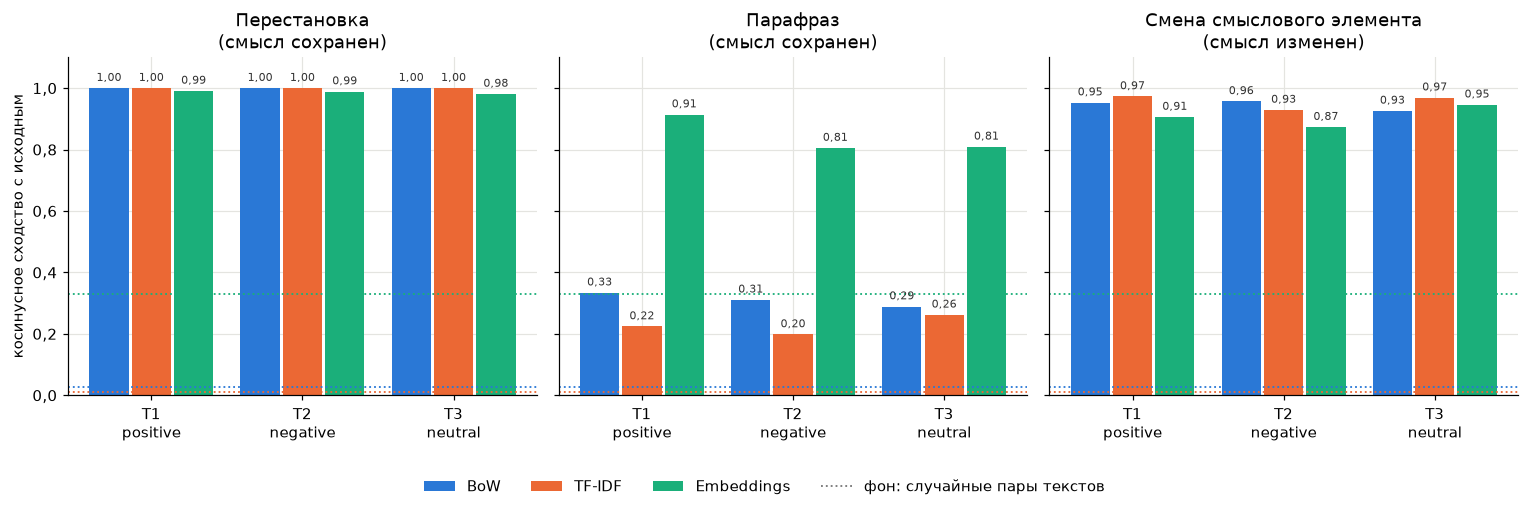

In [13]:
reps = ["BoW", "TF-IDF", "Embeddings"]
titles = {"перестановка": "Перестановка\n(смысл сохранен)", "парафраз": "Парафраз\n(смысл сохранен)",
          "смена смысла": "Смена смыслового элемента\n(смысл изменен)"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
w = 0.28
for ax, (tr, title) in zip(axes, titles.items()):
    sub = res[res["transform"] == tr].reset_index(drop=True)
    x = np.arange(len(sub))
    for j, r in enumerate(reps):
        bars = ax.bar(x + (j - 1) * w, sub[r], w - 0.02, color=COLORS[r], label=r)
        for b, v in zip(bars, sub[r]):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}".replace(".", ","), ha="center",
                    va="bottom", fontsize=7, color="#333")
        ax.axhline(baseline[r], color=COLORS[r], ls=":", lw=1.2)
    ax.set_xticks(x, [f"{k}\n{l}" for k, l in zip(sub["text_key"], sub["label"])])
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(COMMA)
axes[0].set_ylabel("косинусное сходство с исходным")
handles, labels = axes[0].get_legend_handles_labels()
handles.append(plt.Line2D([], [], color="#777", ls=":", lw=1.2))
labels.append("фон: случайные пары текстов")
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("figures/similarity.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Поверхностные признаки исходных и измененных текстов

In [14]:
cols = ["n_chars", "n_words", "n_sents", "mean_word_len", "n_punct", "has_negation"]
rows = []
for key, sid in SOURCES.items():
    rows.append({"текст": key, "вариант": "исходный", **{c: surface(src.loc[sid, "text"])[c] for c in cols}})
    for _, r in res[res["text_key"] == key].iterrows():
        rows.append({"текст": key, "вариант": r["transform"], **{c: surface(r["modified"])[c] for c in cols}})
pd.DataFrame(rows)

,текст,вариант,n_chars,n_words,n_sents,mean_word_len,n_punct,has_negation
0,T1,исходный,56,11,3,3.91,3,1
1,T1,перестановка,56,11,3,3.91,3,1
2,T1,парафраз,72,13,2,4.31,4,1
3,T1,смена смысла,53,10,3,4.10,3,0
4,T2,исходный,120,21,1,4.52,5,0
5,T2,перестановка,120,21,1,4.52,5,0
6,T2,парафраз,124,20,1,5.05,5,0
7,T2,смена смысла,123,21,1,4.67,5,0
8,T3,исходный,45,6,1,6.67,0,0
9,T3,перестановка,45,6,1,6.67,0,0


## 7. Где числа расходятся с изменением смысла

Правило отбора: смысл сохранен, а сходство ниже 0,5, или смысл изменен, а сходство выше 0,85.

In [15]:
long = res.melt(id_vars=["text_key", "transform", "meaning_changed", "modified"], value_vars=reps,
                var_name="representation", value_name="cos")
bad = long[((long["meaning_changed"] == "нет") & (long["cos"] < 0.5)) |
           ((long["meaning_changed"] == "да") & (long["cos"] > 0.85))]
bad.sort_values(["transform", "text_key"])[["text_key", "transform", "meaning_changed", "representation", "cos"]]

,text_key,transform,meaning_changed,representation,cos
1,T1,парафраз,нет,BoW,0.334
10,T1,парафраз,нет,TF-IDF,0.224
4,T2,парафраз,нет,BoW,0.311
13,T2,парафраз,нет,TF-IDF,0.198
7,T3,парафраз,нет,BoW,0.289
16,T3,парафраз,нет,TF-IDF,0.262
2,T1,смена смысла,да,BoW,0.953
11,T1,смена смысла,да,TF-IDF,0.973
20,T1,смена смысла,да,Embeddings,0.906
5,T2,смена смысла,да,BoW,0.957


Проверка: насколько эмбеддинг отличает вариант со сменой смысла от парафраза того же текста. Если отрицательный вариант ближе к исходному, чем парафраз, модель ранжирует хуже человека.

In [16]:
piv = res.pivot(index="text_key", columns="transform", values="Embeddings")
piv["смена ближе парафраза"] = piv["смена смысла"] > piv["парафраз"]
piv

transform,парафраз,перестановка,смена смысла,смена ближе парафраза
text_key,,,,
T1,0.914,0.991,0.906,False
T2,0.805,0.989,0.873,True
T3,0.809,0.981,0.946,True
